# Práctica 4 — Algoritmos de Optimización Basados en Colonias de Hormigas

**SH** (Sistema de Hormigas), **SHE** (Elitista) y **SCH** (Colonias de Hormigas), comparados con un **Greedy aleatorizado de lista corta (3)**.

> Problema P4: sin restricción de capacidad del camión → **TSP** sobre las 16 estaciones. El coste que guía a las hormigas es `C(S) = kms`. Al equilibrarse todo el sistema, la **entropía es constante** por caso (no discrimina); el discriminante es la distancia.

Abre la carpeta **raíz del repositorio** como workspace (esta práctica importa de `Practica_1`).

In [10]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [11]:
import sys
import os

directorio_actual = os.getcwd()
abspath = os.path.abspath(os.path.join(directorio_actual, '..'))

if abspath not in sys.path:
    sys.path.append(abspath)

from Practica_4.runner import (
    ejecutar_experimento_aco,
    ejecutar_tabla_global_aco,
    ejecutar_tabla_parcial_aco,
    _cargar_coords,
    _estaciones_tsp,
)
from Practica_4.config import CASOS, SEMILLAS_P4
from Practica_4.algorithms import sistema_colonias_hormigas
from Practica_4.utils import generar_animacion_feromona, graficar_convergencia_aco
from Practica_1.utils import evaluar_ruta, fobj_ratio

## Tabla 1.1 — Resultados Globales

Mejor resultado de SH / SHE / SCH / Greedy A. en cada caso (mejor de las 3 semillas por `fobj_ratio`).

In [12]:
# Parámetros completos de la consigna (m=10, 1000 iteraciones). Puede tardar.
tabla_global = ejecutar_tabla_global_aco()

## Tabla 1.1 — Resultados Parciales (media y desviación típica)

Las 3 ejecuciones (una por semilla) de cada algoritmo en cada caso, con **Media** y **Desviación** típica.

In [13]:
for algo in ('sh', 'she', 'sch'):
    ejecutar_tabla_parcial_aco(algo)

## Experimentación por algoritmo (convergencia + mejor tour)


 EXPERIMENTACIÓN: SH (SISTEMA DE HORMIGAS)

>> Mejor tour (Caso 1) — Kms=22.90



>> Mejor tour (Caso 2) — Kms=22.90



>> Mejor tour (Caso 3) — Kms=22.90


| Caso   | Score (Ratio)| Kms      | Entropía | Ev. Media | Ev. Total | T.Medio(s)|  Semilla   |
------------------------------------------------------------------------------------------------
| Caso 1 |      1.4331 |    22.90 |  15.9805 |   10000.0 |     10000 |     1.036 |     382941 |
| Caso 2 |      1.4331 |    22.90 |  15.9805 |   10000.0 |     10000 |     1.010 |     382941 |
| Caso 3 |      1.5365 |    22.90 |  14.9053 |   10000.0 |     10000 |     1.087 |     382941 |
------------------------------------------------------------------------------------------------
 Parámetros: m=10, iter=1000, rho=0.1


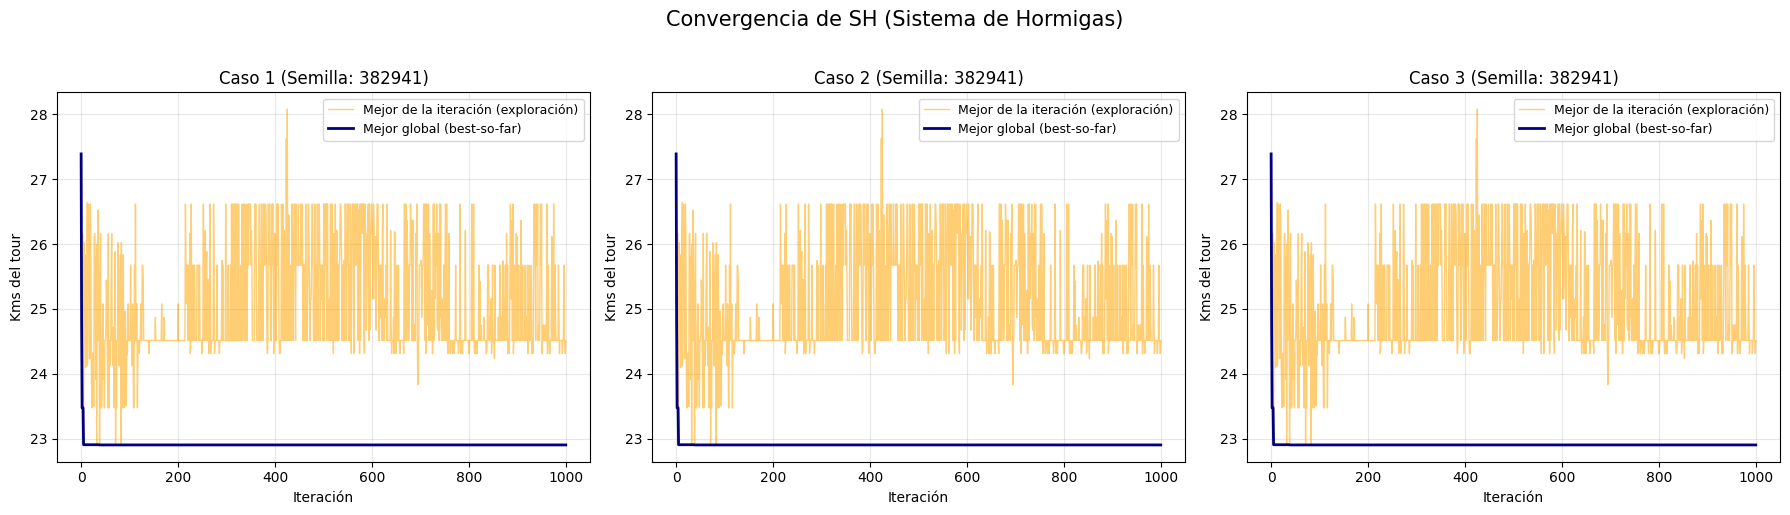

In [14]:
res_sh = ejecutar_experimento_aco('sh', maps=True)


 EXPERIMENTACIÓN: SHE (SISTEMA DE HORMIGAS ELITISTA)

>> Mejor tour (Caso 1) — Kms=22.38



>> Mejor tour (Caso 2) — Kms=22.38



>> Mejor tour (Caso 3) — Kms=22.38


| Caso   | Score (Ratio)| Kms      | Entropía | Ev. Media | Ev. Total | T.Medio(s)|  Semilla   |
------------------------------------------------------------------------------------------------
| Caso 1 |      1.4006 |    22.38 |  15.9805 |   10000.0 |     10000 |     1.047 |   27849102 |
| Caso 2 |      1.4006 |    22.38 |  15.9805 |   10000.0 |     10000 |     1.033 |   27849102 |
| Caso 3 |      1.5016 |    22.38 |  14.9053 |   10000.0 |     10000 |     1.099 |   27849102 |
------------------------------------------------------------------------------------------------
 Parámetros: m=10, iter=1000, rho=0.1, e=5


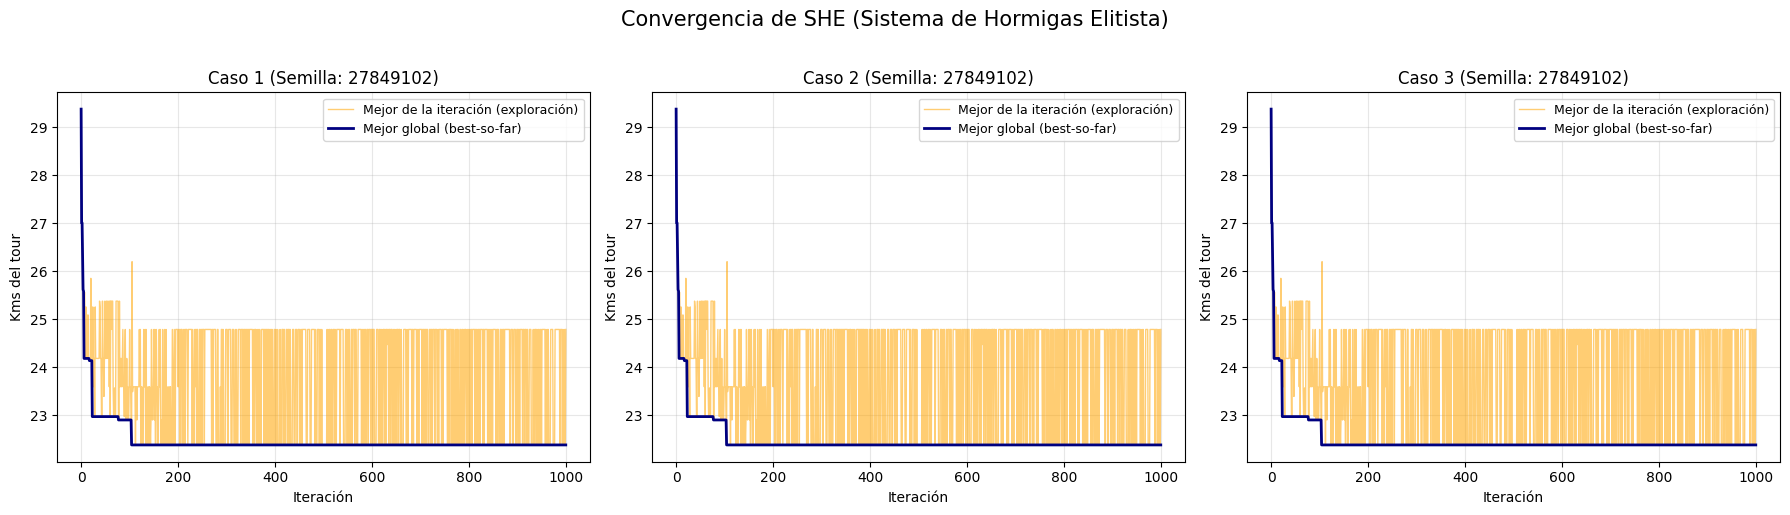

In [15]:
res_she = ejecutar_experimento_aco('she', maps=True)


 EXPERIMENTACIÓN: SCH (SISTEMA DE COLONIAS DE HORMIGAS)

>> Mejor tour (Caso 1) — Kms=22.38



>> Mejor tour (Caso 2) — Kms=22.38



>> Mejor tour (Caso 3) — Kms=22.38


| Caso   | Score (Ratio)| Kms      | Entropía | Ev. Media | Ev. Total | T.Medio(s)|  Semilla   |
------------------------------------------------------------------------------------------------
| Caso 1 |      1.4008 |    22.38 |  15.9805 |   10000.0 |     10000 |     1.601 |     382941 |
| Caso 2 |      1.4008 |    22.38 |  15.9805 |   10000.0 |     10000 |     1.598 |     382941 |
| Caso 3 |      1.5018 |    22.38 |  14.9053 |   10000.0 |     10000 |     1.672 |     382941 |
------------------------------------------------------------------------------------------------
 Parámetros: m=10, iter=1000, rho=0.1, phi=0.1, q0=0.98


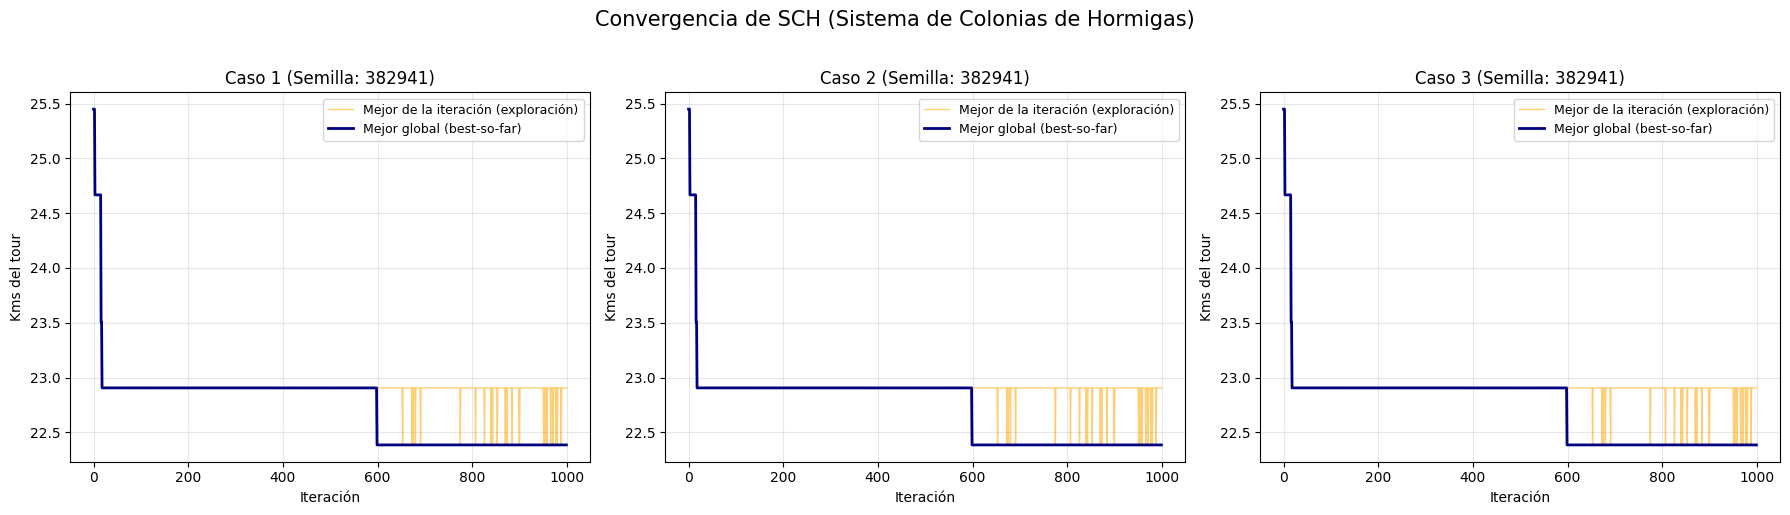

In [16]:
res_sch = ejecutar_experimento_aco('sch', maps=True)

## Estudio de convergencia de SH (parámetros ρ y β)

La curva de convergencia de **SH** forma un "ángulo recto": el *mejor global* (best-so-far) se estanca muy pronto porque la feromona se concentra rápido —todas las hormigas refuerzan en cada iteración y la evaporación es baja—, mientras la curva *mejor de la iteración* muestra que la colonia sigue explorando sin mejorar el récord. (SCH, por contraste, converge de forma gradual.)

Para caracterizar este comportamiento se estudian los dos parámetros que gobiernan el equilibrio exploración/explotación de SH:

- **ρ (evaporación):** una ρ baja conserva la feromona y acelera el bloqueo (ángulo más marcado); una ρ alta la disipa y prolonga la exploración.
- **β (visibilidad):** una β alta vuelve a SH casi voraz (sigue la heurística 1/distancia) y precipita la convergencia; una β baja la ralentiza.

Cada barrido usa una semilla representativa y muestra un subgráfico por valor. Los valores por defecto de la consigna (ρ=0.1, β=2) no se modifican.

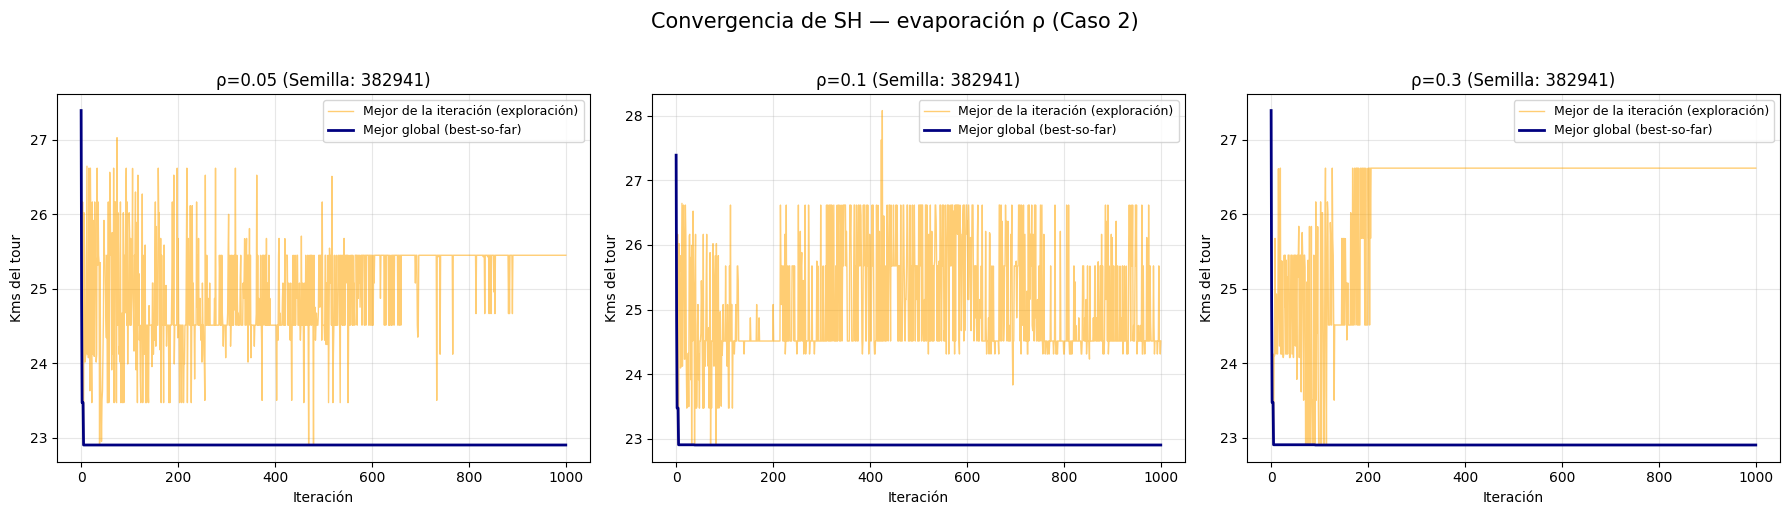

In [17]:
from Practica_4.algorithms import sistema_hormigas

coords_sh = _cargar_coords()
est_sh = _estaciones_tsp(coords_sh)
d_sh = CASOS['Caso 2']
semilla_sh = SEMILLAS_P4[0]

# Barrido de ρ (evaporación): cómo de rápido se concentra la feromona en SH.
datos_rho = []
for rho in (0.05, 0.1, 0.3):
    r = sistema_hormigas(
        funcion_objetivo=fobj_ratio, estaciones_base=est_sh,
        coordenadas=coords_sh, caso_bicis=d_sh['bicis'],
        caso_capacidad=d_sh['capacidad'], evaluar_ruta=evaluar_ruta,
        semilla=semilla_sh, rho=rho)
    datos_rho.append({'historial': r['historial'],
                      'nombre_caso': f"ρ={rho}", 'semilla': semilla_sh})
graficar_convergencia_aco(datos_rho, "SH — evaporación ρ (Caso 2)")

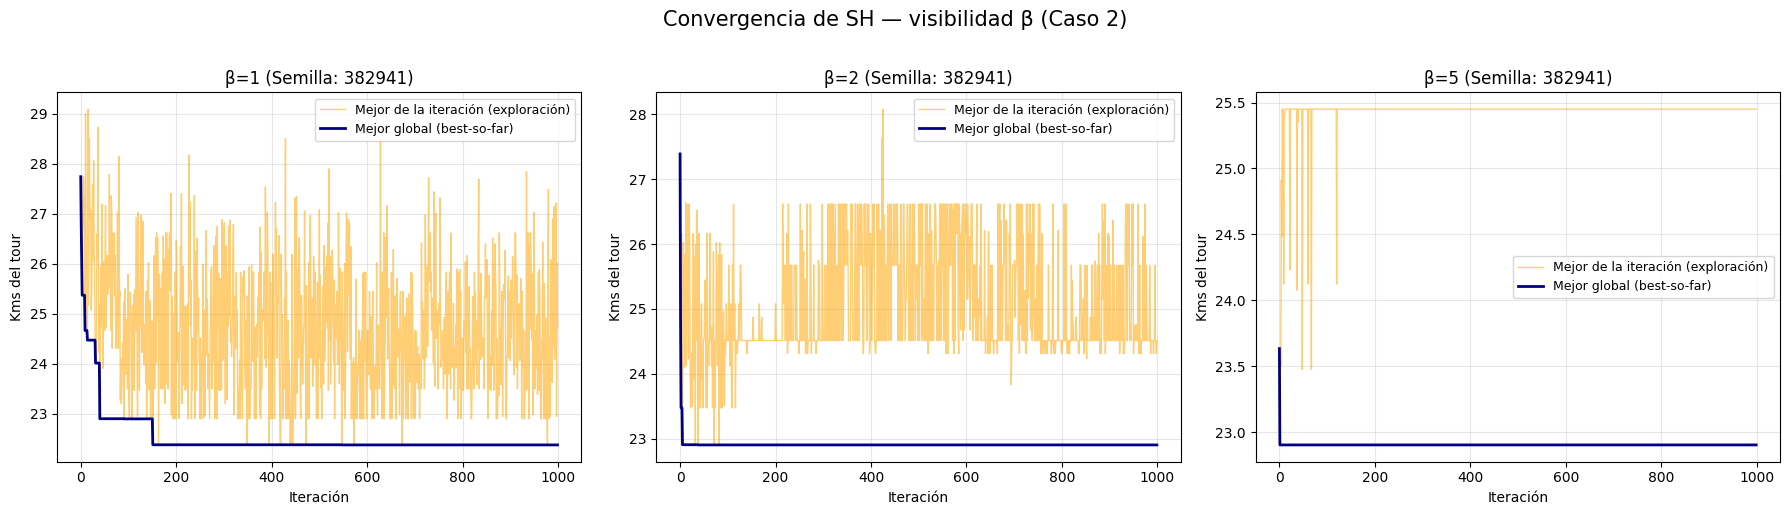

In [18]:
# Barrido de β (visibilidad): cuánto pesa la heurística 1/distancia en SH.
datos_beta = []
for beta in (1, 2, 5):
    r = sistema_hormigas(
        funcion_objetivo=fobj_ratio, estaciones_base=est_sh,
        coordenadas=coords_sh, caso_bicis=d_sh['bicis'],
        caso_capacidad=d_sh['capacidad'], evaluar_ruta=evaluar_ruta,
        semilla=semilla_sh, beta=beta)
    datos_beta.append({'historial': r['historial'],
                       'nombre_caso': f"β={beta}", 'semilla': semilla_sh})
graficar_convergencia_aco(datos_beta, "SH — visibilidad β (Caso 2)")

## Animación interactiva del rastro de feromona

Mapa real de Santander con **barra de tiempo (slider) y play**: el rastro de feromona evoluciona del principio al final de la optimización y el mejor tour de cada instante se resalta en rojo. Usa `folium.plugins.TimestampedGeoJson` — **sin selenium ni navegador externo**.

Ejecuta el algoritmo con `registrar_feromona=True` para capturar los fotogramas (≈50 por defecto).

In [19]:
coordenadas = _cargar_coords()
estaciones = _estaciones_tsp(coordenadas)
datos = CASOS['Caso 1']

res = sistema_colonias_hormigas(
    funcion_objetivo=fobj_ratio, estaciones_base=estaciones,
    coordenadas=coordenadas, caso_bicis=datos['bicis'],
    caso_capacidad=datos['capacidad'], evaluar_ruta=evaluar_ruta,
    semilla=SEMILLAS_P4[0], registrar_feromona=True,
)

snapshots = res['historial']['snapshots_feromona']
print(f'Fotogramas capturados: {len(snapshots)}')
generar_animacion_feromona(coordenadas, snapshots, guardar_html='feromona_sch.html')

Fotogramas capturados: 51
>> [Animación] Mapa interactivo guardado en: feromona_sch.html
